# 1. Data quality and missingness

**Question: what is actually in this data, and is the missingness itself informative?**

Before any model is fit, three properties of the APS data decide most of the modelling
choices that follow: how rare failures are, how much of the matrix is missing, and
whether that missingness is random.

The third question is the interesting one. If a sensor reading is absent more often on
trucks that later fail, then *the absence is a measurement*. Discarding it — by imputing
and moving on — throws away signal. Keeping it, as an explicit indicator column, costs
one extra feature per affected sensor.

No model is fit here.

> **The objective.** Every number in this notebook is judged against
> `J = 10·FP + 500·FN`. A false positive is an unnecessary inspection; a false
> negative is a truck that fails in service. Missing one failure costs as much
> as fifty needless inspections, and that ratio is what makes the modelling
> choices here matter.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from scania_aps.data import TEST_FILENAME, TRAIN_FILENAME, read_raw_csv
from scania_aps.plotting import apply_house_style

ROOT = Path.cwd().resolve()
if ROOT.name == "experiments":
    ROOT = ROOT.parent
TRAIN = ROOT / "data" / "raw" / TRAIN_FILENAME
TEST = ROOT / "data" / "raw" / TEST_FILENAME
ARTIFACTS = ROOT / "artifacts"
assert TRAIN.exists() and TEST.exists(), "Run: poetry run scania-aps download"

apply_house_style()

train = read_raw_csv(TRAIN)
test = read_raw_csv(TEST)

pd.DataFrame(
    {
        "trucks": [len(train.y), len(test.y)],
        "features": [train.X.shape[1], test.X.shape[1]],
        "failures": [int(train.y.sum()), int(test.y.sum())],
        "failure_rate": [train.y.mean(), test.y.mean()],
    },
    index=["training set", "official test set"],
)

,trucks,features,failures,failure_rate
training set,60000,170,1000,0.016667
official test set,16000,170,375,0.023438


## How rare is a failure?

The failure rate sets the difficulty. At roughly 1.7% positive, a classifier that
predicts "no failure" for every truck is right 98.3% of the time — and useless. This
single number is why accuracy is not the target anywhere in this repository.

In [2]:
failure_rate = train.y.mean()
print(f"training failures: {int(train.y.sum()):,} of {len(train.y):,}  ({failure_rate:.2%})")
print(f"negatives per positive: {(1 - failure_rate) / failure_rate:.0f} : 1")
print()
print(f"An always-negative classifier scores {1 - failure_rate:.2%} accuracy")
print(f"and misses every one of the {int(test.y.sum()):,} failures in the test set.")

training failures: 1,000 of 60,000  (1.67%)
negatives per positive: 59 : 1

An always-negative classifier scores 98.33% accuracy
and misses every one of the 375 failures in the test set.


## How much is missing?

The features are anonymised sensor aggregates. Some are nearly complete; others are
absent for most trucks. The chart below ranks the twenty emptiest columns.

A single hue is used deliberately: this is one quantity measured across many columns, so
colour carries no extra information and length already encodes the magnitude.

columns with any missing values: 169 of 170
worst column: br_000 at 82.1% missing
median column: 1.1% missing


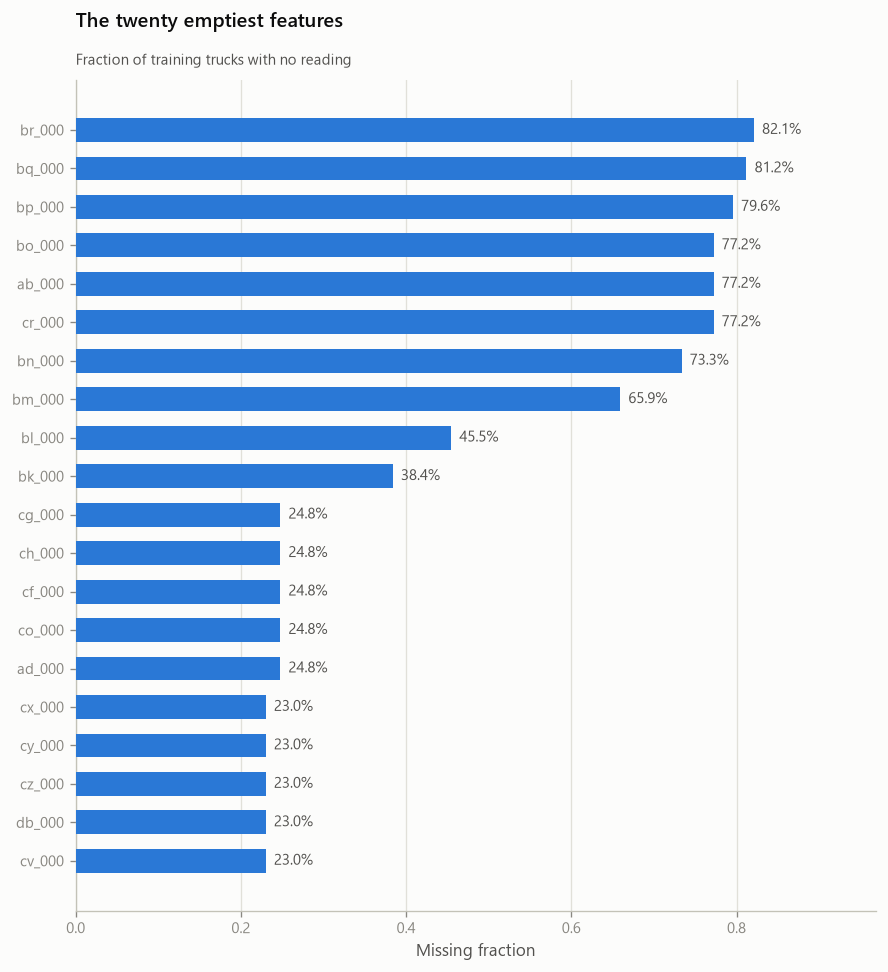

In [3]:
from scania_aps.plotting import magnitude_bars

missing = train.X.isna().mean().sort_values(ascending=False)

print(f"columns with any missing values: {(missing > 0).sum()} of {len(missing)}")
print(f"worst column: {missing.index[0]} at {missing.iloc[0]:.1%} missing")
print(f"median column: {missing.median():.1%} missing")

top_missing = missing.head(20)
fig, ax = magnitude_bars(
    list(top_missing.index),
    [float(v) for v in top_missing.to_numpy()],
    title="The twenty emptiest features",
    subtitle="Fraction of training trucks with no reading",
    xlabel="Missing fraction",
    value_format="{:.1%}",
)

## Is the missingness informative?

Now the question that matters. For each feature, compare how often it is missing on
trucks that failed against trucks that did not.

If missingness were random, every bar would sit at zero. It does not. Features are
shown by the size of the gap, with the sign preserved: to the right means the sensor is
missing **more often on failed trucks**, to the left means more often on healthy ones.
Two hues that read as opposite, with zero as a neutral midpoint.

,healthy,failed,gap
br_000,0.833458,0.090,-0.743458
bq_000,0.824322,0.087,-0.737322
bp_000,0.807746,0.083,-0.724746
bo_000,0.783983,0.078,-0.705983
bn_000,0.744661,0.074,-0.670661
bm_000,0.669119,0.071,-0.598119
ak_000,0.065559,0.532,0.466441
ca_000,0.064847,0.530,0.465153
di_000,0.059017,0.524,0.464983
dj_000,0.059034,0.524,0.464966


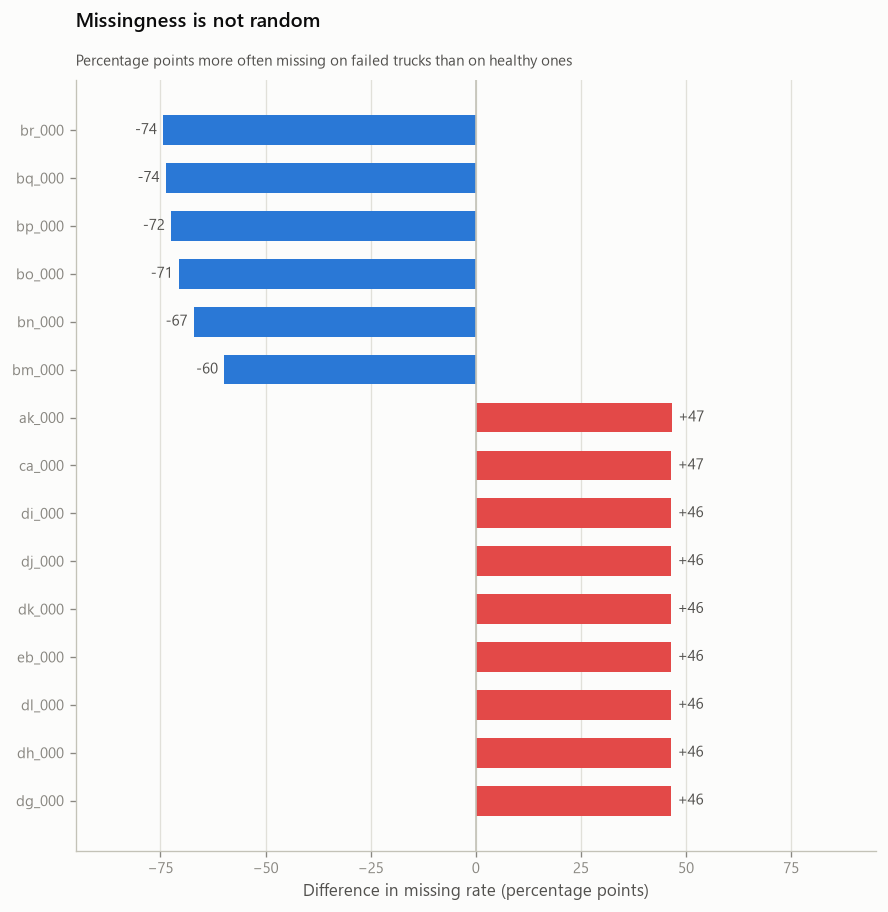

In [4]:
from scania_aps.plotting import diverging_bars

by_class = train.X.isna().groupby(train.y).mean().T
by_class.columns = ["healthy", "failed"]
by_class["gap"] = by_class["failed"] - by_class["healthy"]

ranked = by_class.reindex(by_class["gap"].abs().sort_values(ascending=False).index)
top_gap = ranked.head(15)

fig, ax = diverging_bars(
    list(top_gap.index),
    [float(v) * 100 for v in top_gap["gap"].to_numpy()],
    title="Missingness is not random",
    subtitle="Percentage points more often missing on failed trucks than on healthy ones",
    xlabel="Difference in missing rate (percentage points)",
)

ranked.head(15)

### What this means for the pipeline

The gaps are large — tens of percentage points on the worst features, in both
directions. Missingness is associated with the outcome, so it is a feature, not a
nuisance.

That is why every pipeline in this repository imputes with
`SimpleImputer(strategy="median", add_indicator=True)`. The median fills the hole so
the estimator can run; the indicator column preserves the fact that there *was* a hole.
Dropping the indicator would discard the signal this chart just measured.

The median is chosen over the mean because these columns are heavily skewed — see
below.

In [5]:
spread = pd.DataFrame(
    {
        "missing_fraction": missing,
        "median": train.X.median(),
        "mean": train.X.mean(),
        "max": train.X.max(),
    }
)
spread["mean_over_median"] = spread["mean"] / spread["median"].replace(0, np.nan)
spread.sort_values("missing_fraction", ascending=False).head(15)

,missing_fraction,median,mean,max,mean_over_median
br_000,0.821067,320400.0,604886.613264,1.310700e+06,1.887911
bq_000,0.812033,305100.0,582871.322930,1.310700e+06,1.910427
bp_000,0.795667,288320.0,551389.799347,1.310700e+06,1.912423
bo_000,0.772217,270660.0,513147.820297,1.310700e+06,1.895913
ab_000,0.772150,0.0,0.713189,2.040000e+02,NaN
cr_000,0.772150,0.0,37.062980,5.745000e+04,NaN
bn_000,0.733483,251400.0,463710.833594,1.310700e+06,1.844514
bm_000,0.659150,239140.0,399603.167571,1.310700e+06,1.671001
bl_000,0.454617,222540.0,321353.687009,1.310700e+06,1.444027
bk_000,0.383900,210660.0,280429.114321,1.310700e+06,1.331193


The mean sits well above the median on most columns, confirming long right tails.
Imputing with the mean would push filled values into a range almost no real truck
occupies; the median stays inside the bulk of the distribution.

**Next:** [02 — cost-sensitive baselines](02_cost_sensitive_baselines.ipynb) establishes
what the trivial policies cost, which is the bar every model has to clear.